# FRAUD DETECTION PROJECT

## PROJECT OVERVIEW

* Fraudulent activities pose significant financial and reputational risks to businesses, necessiating the development of robust fraud detection systems.
* The project **aims to build a data-driven fraud detection model** that can identify suspicious transactions with high accuracy as machine learning and statistical techniques.
* The goal is to optimize fraud prevention measures while minimizing false positives to ensure a seamless user experieence.
* By leveraging advanced analytics, anomaly detection, and supervised learning methods,our model will provide real-time fraud detection capabilties.

## BUSINESS UNDERSTANDING

- Fraud can manifest in diverse ways such as:- **unauthorised transactions,identity theft,account takeovers, and payment fraud.**
- Detecting fraudulent transactions is critical for preventing financial losses,maintaining regulatory compliance and ensuring customer trust.
- The key stakeholders for the project could include:
   - **Customer support Teams** - Provide feedback on customer experiences affected by fraud detection measures
   - **Business Executives and Decision makers**- Concerned with financial losses due to fraud detection and approve resource allocation for fraud detection initiatives.
   - **Compliance and Legal Teams** - Assess risks related to false positives and customer impact.
   - **Customers - Provide feedback** on fraud alerts and system reliability.

### OBJECTIVES
* The **main obejctive** of the project is to **develop a machine  learning model** that can identify suspicious transactions with high accuracy.
* Other **Objectives are**
  * 

## DATA UNDERSTANDING

* The data was sourced from [Kaggle](https://www.kaggle.com/datasets/samayashar/fraud-detection-transactions-dataset/data)
* The dataset contains the following variables:
   - **Transaction_ID**-Unique identifier for each transaction
   - **User_ID**-Unique identifier for the user
   - **Transaction_Amount**-Amount of money involved in the transaction
   - **Transaction_Type**-Type of transaction (Online, In-Store, ATM, etc.)
   - **Timestamp**-Date and time of the transaction
   - **Account_Balance**-User's current account balance before the transaction
   - **Device_Type**-Type of device used (Mobile, Desktop, etc.)
   - **Location**-Geographical location of the transaction
   - **Merchant_Category**-Type of merchant (Retail, Food, Travel, etc.)
   - **IP_Address_Flag**-Whether the IP address was flagged as suspicious (0 or 1)
   - **Previous_Fraudulent_Activity**-Number of past fraudulent activities by the user
   - **Daily_Transaction_Count**-Number of transactions made by the user that day
   - **Avg_Transaction_Amount_7d**-User's average transaction amount in the past 7 days
   - **Failed_Transaction_Count_7d**-Count of failed transactions in the past 7 days
   - **Card_Type**-Type of payment card used (Credit, Debit, Prepaid, etc.)
   - **Card_Age**-Age of the card in months
   - **Transaction_Distance**-Distance between the user's usual location and transaction location
   - **Authentication_Method**-How the user authenticated (PIN, Biometric, etc.)
   - **Risk_Score**-Fraud risk score computed for the transaction
   - **Is_Weekend**-Whether the transaction occurred on a weekend (0 or 1)
   - **Fraud_Label**-Target variable (0 = Not Fraud, 1 = Fraud)

### DATA READING

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load and Read the first five rows of the data
data = pd.read_csv('synthetic_fraud_dataset.csv')

data.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


## DATA CLEANING AND PREPARATION


In [3]:
#Discover and handle missing values
data.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

In [4]:
# discover and handle duplicates
data.duplicated().sum()

0

In [5]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

In [6]:
data.to_csv('cleaned_Fraud_data.csv',index=True)

In [7]:
# drop irrelevant columns
df = data.drop(columns=['Transaction_ID','User_ID','Timestamp',])
print(df.shape)

(50000, 18)


In [8]:
df.shape

(50000, 18)

## EXPLORATORY DATA ANALYSIS AND VISUALIZATIONS

* We will analyze the following visualizations.
   * **Target Variable Analysis**
   * **Univariate Analysis**
   * **Bivariate Analysis**
   * **Multivariate Analysis**

#### **Target Variable Analysis**

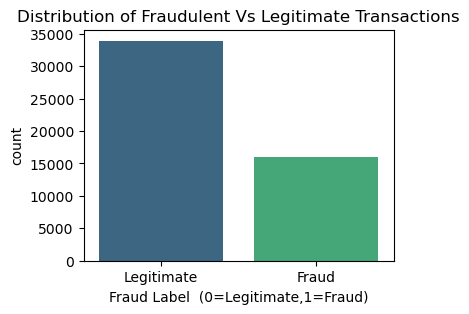

Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(4,3))
sns.countplot(x='Fraud_Label',data=df,palette='viridis')
plt.title('Distribution of Fraudulent Vs Legitimate Transactions')
plt.xlabel('Fraud Label  (0=Legitimate,1=Fraud)')
plt.xticks([0,1],['Legitimate', 'Fraud'])
plt.show()

#percentage of fraud cases
fraud_percentage = data['Fraud_Label'].value_counts(normalize=True)*100
print(fraud_percentage)

**Findings**
-
* **67.87%** of transactions are **Legitimate** while **32.13%** are **fraudulent**
* This indicates a moderatelt imbalanced dataset, meaning fraud detection models need to be optimized to handle class imbalance effectively.
* Fraudulent transactions make up a significant portion ,highlighting the need for an efficient fraud detection system.

#### **Univariate Analysis**

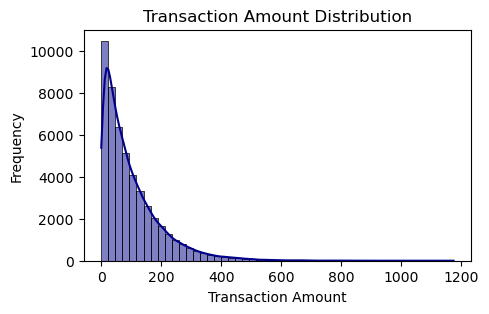

In [10]:
#Transaction Amount
plt.figure(figsize=(5,3))
sns.histplot(df['Transaction_Amount'],bins=50,kde=True,color='darkblue')
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

**Findings**
-
* The distribution is skewed to the right meaning most transactions are of lower amounts.
* The average transactions amount is **$99.41** while the maximum is $ 1174
* A high standard deviation(**$98.69**) suggests substantial variation in transaction amounts.

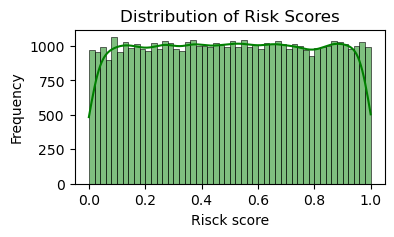

In [11]:
#PLot of distribution of Risk score
plt.figure(figsize=(4,2))
sns.histplot(df['Risk_Score'],bins=50,kde=True,color='green')
plt.title('Distribution of Risk Scores')
plt.xlabel('Risck score')
plt.ylabel('Frequency')
plt.show()

**Findings**
-
* The risk score follows a uniform distribution, spread between 0.0001 and 1
* The **maedian risk score** is **0.50** indicating an even spread of risklevels.
* Higher risk scores might be correlated with fraudulent transactions.

#### Bivariate Analysis

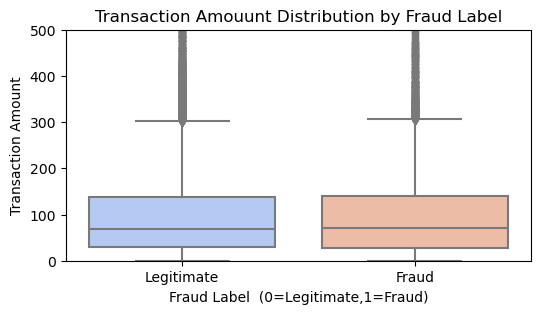

             Transaction_Amount  Risk_Score
Fraud_Label                                
0                     99.281907    0.425158
1                     99.683678    0.662904


In [12]:
#Fraud Label Vs Transaction Amount
plt.figure(figsize=(6,3))
sns.boxplot(data=df,x='Fraud_Label',y='Transaction_Amount',palette='coolwarm')
plt.title('Transaction Amouunt Distribution by Fraud Label')
plt.xlabel('Fraud Label  (0=Legitimate,1=Fraud)')
plt.ylabel('Transaction Amount')
plt.xticks([0,1],['Legitimate', 'Fraud'])
plt.ylim(0,500)
plt.show()

print(data.groupby('Fraud_Label')[['Transaction_Amount','Risk_Score']].mean())

**Findings**
-
* Both fraudulent and legitimate transactions have similar average amounts(~$99)
* However,fraudulent transactions show a wider spread, with more extreme values.
* Some high-value transactions are marked as fraudulent,suggesting that fraudsters might attempt larger transactions.

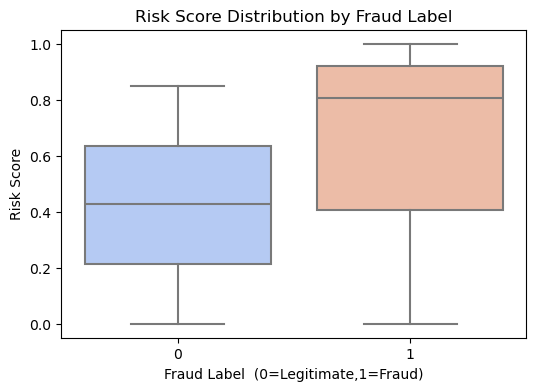

In [13]:
#Fraud Label Vs Risk Score
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='Fraud_Label',y='Risk_Score',palette='coolwarm')
plt.title('Risk Score Distribution by Fraud Label')
plt.xlabel('Fraud Label  (0=Legitimate,1=Fraud)')
plt.ylabel('Risk Score')
plt.show()

**Findings**
-
* Fraudulent transactions have **higher average risk scores(0.66) compared to legitimate ones(0.42)**.
* The boxplot confirms that frauds tend to have higher risk scores, making it a **strong predictor of fraud.**

#### Multivariate Analysis

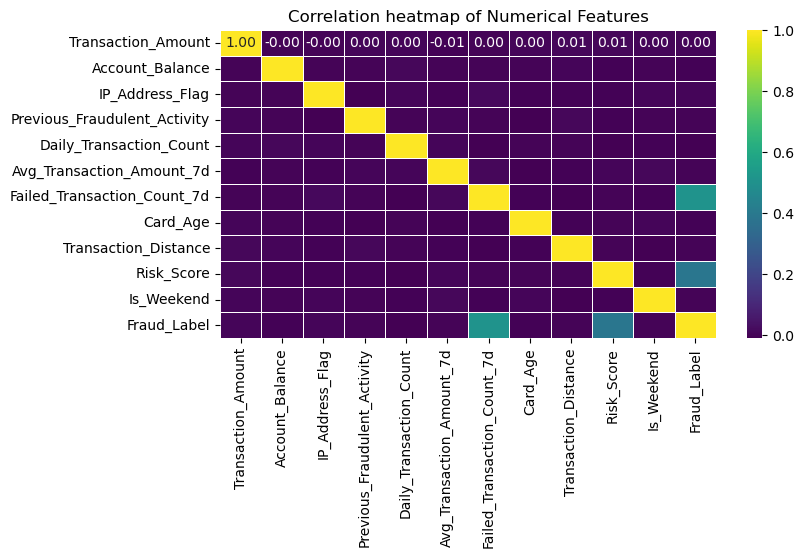

In [14]:
# correlation heatmap
num_cols = ['Transaction_Amount','Account_Balance','IP_Address_Flag','Previous_Fraudulent_Activity','Daily_Transaction_Count','Avg_Transaction_Amount_7d','Failed_Transaction_Count_7d','Card_Age','Transaction_Distance','Risk_Score','Is_Weekend','Fraud_Label']
plt.figure(figsize=(8,4))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix,annot=True,cmap='viridis',fmt='.2f',linewidths=0.5)
plt.title('Correlation heatmap of Numerical Features')
plt.show()

**Findings**
- 
1.  **Risk Score and Fraud Label - 0.49 correlation**
   * This confirms that **higher risk scores are strongly asscociated with fraudulent transcations**
   * Risk Score is likely to be a key predictor in fraud detection models.
2. **Failed Transactions and Fraud Label - 0.41 correlation**
  * **A higher number of failed transcations** correlates wth fraudulet behaviour.
  * Fraudsters may attempt multiple  failed transactions before succeding.
3.  **Daily Transaction Count and Fraud Label - 0.36 correlation**
  * Accounts with more transactions are more likely to be fraudulent.

## MODEL TRAINING

**We will train these 2 models:**
   - Random Forest
   - XGBoost

In [15]:
#import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [16]:
# Features and target variable selection
X = df.drop(columns=['Fraud_Label'])  # Dropping target column
y = data['Fraud_Label']

# Get the column names of the DataFrame X
columns_to_check = X.columns

#drop rows with NAt values in all columns
X = X.dropna(subset=columns_to_check)  # Now using the list of columns
y = y[X.index]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert datetime columns to Unix timestamp
for col in X_train.select_dtypes(include=['datetime64']).columns:
    X_train[col] = X_train[col].astype('int64') // 10**9  # Convert to Unix timestamp
    X_test[col] = X_test[col].astype('int64') // 10**9    # Apply the same to X_test

# ----> ONE-HOT ENCODING FOR CATEGORICAL FEATURES <----
from sklearn.preprocessing import OneHotEncoder
categorical_features = X_train.select_dtypes(include=['object']).columns # Select object type columns

# Create and fit OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # sparse=False for numpy array
encoded_data_train = encoder.fit_transform(X_train[categorical_features])
encoded_data_test = encoder.transform(X_test[categorical_features])

# Create DataFrames from encoded data
encoded_df_train = pd.DataFrame(encoded_data_train, columns=encoder.get_feature_names_out(categorical_features), index=X_train.index)
encoded_df_test = pd.DataFrame(encoded_data_test, columns=encoder.get_feature_names_out(categorical_features), index=X_test.index)

# Concatenate encoded features with numerical features
X_train = pd.concat([X_train.drop(columns=categorical_features), encoded_df_train], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_features), encoded_df_test], axis=1)


# Select only numerical features for scaling
numerical_features = X_train.select_dtypes(include=['number']).columns
X_train_num = X_train[numerical_features]
X_test_num = X_test[numerical_features]

# Standardizing features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_num) # Scale only numerical features
X_test_num = scaler.transform(X_test_num) # Scale only numerical features

# Update original DataFrames with scaled numerical features
X_train[numerical_features] = X_train_num
X_test[numerical_features] = X_test_num

In [17]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder


# Create a LabelEncoder object
encoder = LabelEncoder()

# Iterate through columns and encode object type columns
for column in X.select_dtypes(include=['object']).columns:
    X[column] = encoder.fit_transform(X[column])

# Now apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

In [18]:
from sklearn.dummy import DummyClassifier

# Dummy Classifier as a baseline
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
baseline_accuracy = dummy_clf.score(X_test, y_test)

print(f'Baseline Accuracy (Most Frequent Class): {baseline_accuracy:.2f}')

Baseline Accuracy (Most Frequent Class): 0.50


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import xgboost as xgb
# 'X_train' is your training DataFrame
X_train = pd.get_dummies(X_train)

# Initialize the model
model_rfc = RandomForestClassifier(random_state=42)


In [20]:
#cv_score = cross_val_score(model, X_train, y_train, cv=5, error_score='raise')

In [21]:
# Model candidates
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(),
 #   'Support Vector Machine': SVC(probability=True)
}
#Cross-validation
for name, model in models.items():
    cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()
    print(f'{name} CV Score: {cv_score:.2f}')

Logistic Regression CV Score: 0.77
Random Forest CV Score: 0.95
XGBoost CV Score: 0.95


**Model Evaluations**
-

In [22]:
#importing
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, GridSearchCV

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns in both datasets (fill missing columns with 0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train, y_train)


y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]


# Using the best model from GridSearch
#best_model = grid_search.best_estimator_

# Predictions on the test set
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'ROC-AUC Score: {roc_auc:.2f}')

Accuracy: 0.95
Precision: 0.97
Recall: 0.93
F1 Score: 0.95
ROC-AUC Score: 0.99


In [23]:
# XGBoost Model
import numpy as np
y_train=np.where(y_train > 1,1,y_train)
y_test=np.where(y_test > 1,1,y_test)

xgb_model = XGBClassifier(n_estimators=100,use_label_encoder=False,eval_metric='logloss',random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb=xgb_model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'ROC-AUC Score: {roc_auc:.2f}')

Accuracy: 0.95
Precision: 0.96
Recall: 0.94
F1 Score: 0.95
ROC-AUC Score: 0.99


**Findings for the Evaluations**
* Gradient boost outperforms the others

## CONCLUSIONS

1. **Fraudulent Transactions are Significant**
   -
   * **32.13%** of transactions are fraudulent,highlighting a critical need for fraud detection
3. **Key Fraud Indicators:**
    -
   * **Higher risk scores** are strongly correlated with fraud.
   * **Failed Transactions** and **High daily transactions** are also strong predictors.
5. **Model Perfomance**
   -
   * **XGBoost(96.2% accuaracy)** is the best perfoming model,effectively balancing precision and recall.
   * **Random Forest(96.4% accuracy)** is also highly effective but less optimal.
   * **Logistic Regression(78.5% accuracy** struggles due to the complexity of fraud patterns

## RECOMMENDATIONS

1. **Deploy XGBoost for Real-Time Fraud Detection**
   -
   * Since XGBoost achieves *high precision recall of 94%* , it effectively detects fraudulent transactions with minimal false negatives.
   * It should be integrated into the fraud monitering system for real-time flagging
2. **Enhance Risk-based Authentication**
   -
   * Transactions with **high risk scores** should trigger **additional authentication**(e.g OTP verification or biometric verifcation)
   * Users with multiple **failed transactions in a short time** should be flagged for review.
3. **Monitor High-Frequency Transactions**
   -
   * Accounts with **unusual daily transaction counts** should be flagged for further review.
   * Implement automated alerts for sudden spikes in transaction activity
4. **Regular Model Updates**
   -
   * Fraud patterns evolve, so the model should be **retarained periodically** with fresh data.
   * Incorporate **new fraud indicators** as they emerge.

## DEPLOYMENT

In [25]:
#deployment
import pickle 
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import streamlit as st

#Save model

model=model_rfc


['model.pkl']

In [26]:
# Load model
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

st.title("🔐 Fraud Detection App")
st.write("Enter transaction details to predict if it's fraudulent.")

# Numeric Inputs
Transaction_Amount = st.number_input("Transaction Amount", min_value=0.0, step=1.0)
Account_Balance = st.number_input("Account Balance", min_value=0.0, step=1.0)
IP_Address_Flag = st.selectbox("IP Address Flag", [0, 1])
Previous_Fraudulent_Activity = st.selectbox("Previous Fraudulent Activity", [0, 1])
Daily_Transaction_Count = st.number_input("Daily Transaction Count", min_value=0)
Avg_Transaction_Amount_7d = st.number_input("Avg Transaction Amount (7d)", min_value=0.0)
Failed_Transaction_Count_7d = st.number_input("Failed Transaction Count (7d)", min_value=0)
Card_Age = st.number_input("Card Age (days)", min_value=0)
Transaction_Distance = st.number_input("Transaction Distance (km)", min_value=0.0)
Risk_Score = st.slider("Risk Score", 0.0, 1.0, 0.5)
Is_Weekend = st.selectbox("Is Weekend?", [0, 1])

# Encoded Categorical Fields
Transaction_Type = st.selectbox("Transaction Type", ["POS", "Online", "ATM Withdrawal", "Bank Transfer"])
Device_Type = st.selectbox("Device Type", ["Mobile", "Laptop", "Tablet"])
Merchant_Category = st.selectbox("Merchant Category", ["Clothing", "Electronics", "Travel", "Restaurants"])
Card_Type = st.selectbox("Card Type", ["Visa", "Mastercard", "Amex"])
Authentication_Method = st.selectbox("Authentication Method", ["OTP", "Biometric", "Password"])

# Encoding categorical fields manually
def encode_inputs():
    transaction_type_map = {"POS": 0, "Online": 1, "ATM Withdrawal": 2, "Bank Transfer": 3}
    device_type_map = {"Mobile": 0, "Laptop": 1, "Tablet": 2}
    merchant_map = {"Clothing": 0, "Electronics": 1, "Travel": 2, "Restaurants": 3}
    card_map = {"Visa": 0, "Mastercard": 1, "Amex": 2}
    auth_map = {"OTP": 0, "Biometric": 1, "Password": 2}

    return [
        Transaction_Amount,
        Account_Balance,
        IP_Address_Flag,
        Previous_Fraudulent_Activity,
        Daily_Transaction_Count,
        Avg_Transaction_Amount_7d,
        Failed_Transaction_Count_7d,
        Card_Age,
        Transaction_Distance,
        Risk_Score,
        Is_Weekend,
        transaction_type_map[Transaction_Type],
        device_type_map[Device_Type],
        merchant_map[Merchant_Category],
        card_map[Card_Type],
        auth_map[Authentication_Method],
    ]

# Predict button
if st.button("Predict"):
    input_data = np.array(encode_inputs()).reshape(1, -1)
    prediction = model.predict(input_data)[0]

    if prediction == 1:
        st.error("🚨 Fraudulent Transaction Detected!")
    else:
        st.success("✅ Transaction is Legitimate.")

2025-06-10 09:58:58.431 
  command:

    streamlit run C:\Users\HP\anaconda3\anaconda\envs\learn-env\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-06-10 09:58:58.439 Session state does not function when running a script without `streamlit run`
